
$$
\Large{\textbf{
  Polutant dispersion: deterministic and stochastic models
  }}
$$

$$
\large{\text{
  Johannes Löppönen, Arvid Hedin, Elis Graipe
  }}
$$
$$
\ \\
\ \\
\ \\
\ \\
\ \\
$$

# Introduction


This project aims to model the dispersion of pollutant particles in air, from combustion. The dispersion can be described using a partial differental equation but in this project the dispersion will be modeled using a stochastic simulation utilizing a random walk for each polutant particle.



# Approach and method

The mathematical modeling of pollutant dispersion relies on a difference in view models from macroscopic and microscopic perspectives. In the macroscopic viewpoint the pollutant is viewed as a concentration field $C(x, t)$, whose change is determined by the deterministic advection-diffusion equation:

$$\frac{\partial C}{\partial t} + \nabla \cdot (uC) = D\nabla^{2}C$$

This formulation handles the transport process as a continuous flow where the term $\nabla \cdot (uC)$ represents the advective change in position described by the velocity field u, and $D\nabla^{2}C$ describes the diffusion which is governed by the constant D which determines the velocity of the spread. This perspective is deterministic, which gives a predictable description of the pollutants change over time.

For contrast, the microscopic viewpoint instead focuses on the direction of each individual particle X(t). The motion is now instead described by an Itô stochastic differential equation.

$$dX(t) = u(X(t), t)dt + \sqrt{2D}dB(t)$$

In this case the particle's movement is the result of the deterministic advection component and a stochastic diffusion component given by Brownian motion B(t). This results in the path of any single particle being random and unpredictable.

The connection between these two models is provided by the Fokker-Planck equation. This equation says that the probability density function f(x, t), of the particles trajectory satisfies the same PDE as in the macroscopic concentration field.

This leads to the deterministic plume we observe at a large scale being the statistical result of thousands of independent, random particle scale occurances. In this project, we use this link by simulating an sum of particles and using a Monte Carlo approximated Gaussian kernel $\delta_{\epsilon}$ to visualize the continuous concentration field.

$$C(x, t) \approx \frac{1}{N} \sum_{k=1}^{N} \delta_{\epsilon}(x - X^{k}(t))$$

This way of modeling illustrates how a complex process can be split up into simple stochastic rules and applied individual particles. This as a concequence allows for concentration field to be estimated through Monte Carlo simulation rather than direct numerical solving of the PDE.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1

## Numerical simulation

The Euler-Maruyama method is implemented to solve the stochastic differential equation (SDE) in Task 1. The Euler-Maruyama method is used to numerically integrate the SDE. It integrates the SDE over time for $N$ particles that are independent of each other. 

The iterative method that describes the next position in time for the particles following a starting position $X_0$ is give by

$\mathbf{X}_{n+1} = \mathbf{X}_n + \mathbf{u}h + \sqrt{2Dh}\mathbf{Z}_n, \quad \mathbf{z}_n \sim \mathcal{N}(\mathbf{0}, I_2)$

where $h$ is the time step and $I_2$ is the identity matrix.

In the code the function euler implements the above Euler-Maruyama method. It simulates the positions for $N$ particles in the time interval $[0, T]$. The function returns a list of arrays with the positions of the particles at the times specified by the function argument snapshots.

In [3]:
def euler(N, T, h, D, u, num_steps, checkpoints, q):
    X = np.zeros((N, 2))
    particles_per_step = int(q * h) 
    t = np.linspace(0, T, num_steps + 1)

    snapshots = []

    for n in range(num_steps + 1):
        new_particles = np.zeros((particles_per_step, 2))
        X = np.vstack([X, new_particles])
        
        num_active = X.shape[0]
        Z = np.random.randn(num_active, 2)
        X = X + u * h + np.sqrt(2 * D * h) * Z        
        
        if any(np.isclose(t[n], checkpoints)):
            snapshots.append(X.copy())

    return snapshots

Using the implementation of the Euler-Maruyama method in the euler function we compute the positions of $N$ number of particles at different times $T$ after 0. The particles originate at the point $\mathbf{X}_0 = (0,0)$ and are visualized in a plot showing how the particles have dispersed by $T$ seconds. The area shown is a rectangle constrained to $X

In [ ]:
# Constants

N = 2000         
T = 60       
h = 0.1         
D = 0.02
epsilon = 0.1

u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

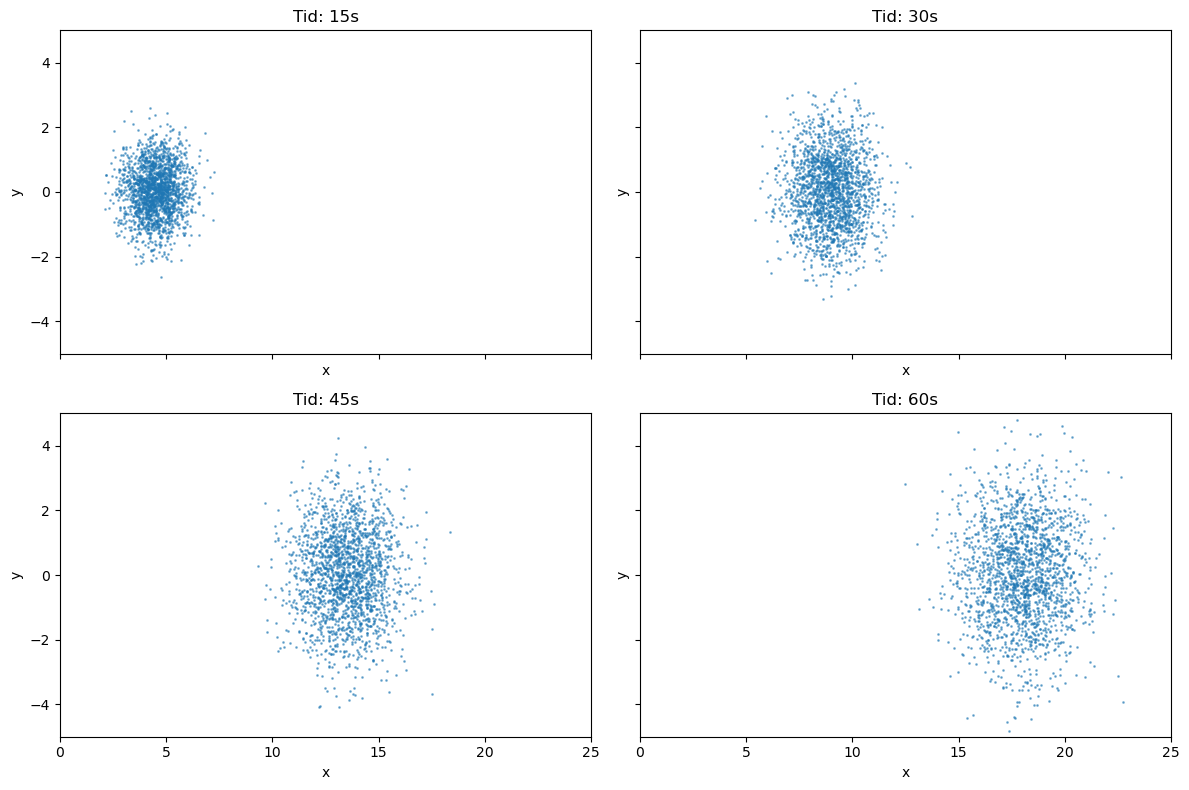

In [4]:
# Plot

snapshots = euler(N,T,h,D,u,num_steps, checkpoints, 0) # No source term
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

# Task 2

In [5]:
def delta_eps(dist, epsilon):
    fac = 1/(2*np.pi*epsilon**2)
    e = np.exp(-dist / (2*epsilon**2))
    return fac * e

def compute_concentration(x_grid, y_grid, snapshot, epsilon):
    N = snapshot.shape[0] #Ammount of particles at time t
    C = np.zeros(x_grid.shape)

    for k in range(N):
        dist = ((x_grid - snapshot[k,0])**2 + (y_grid - snapshot[k,1])**2)
        C += delta_eps(dist, epsilon)

    return C / N

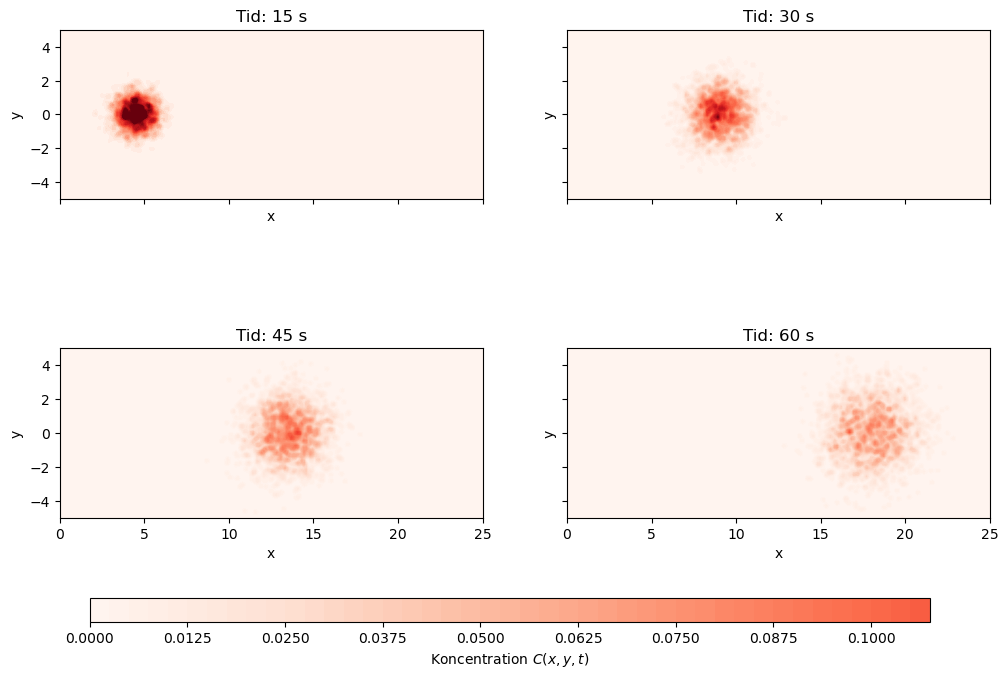

In [6]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

# Run the simulation from task 1
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,0)

for i in range(len(snapshots)):
    X = snapshots[i]
    C = compute_concentration(x_grid, y_grid, X, epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_aspect('equal')
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Koncentration $C(x,y,t)$')

plt.show()

# Task 3

Paragraf efter rubrik

## a

In [7]:
# Constants
N = 0         
T = 60       
h = 0.1         
D = 0.02     
Q = 100    
u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

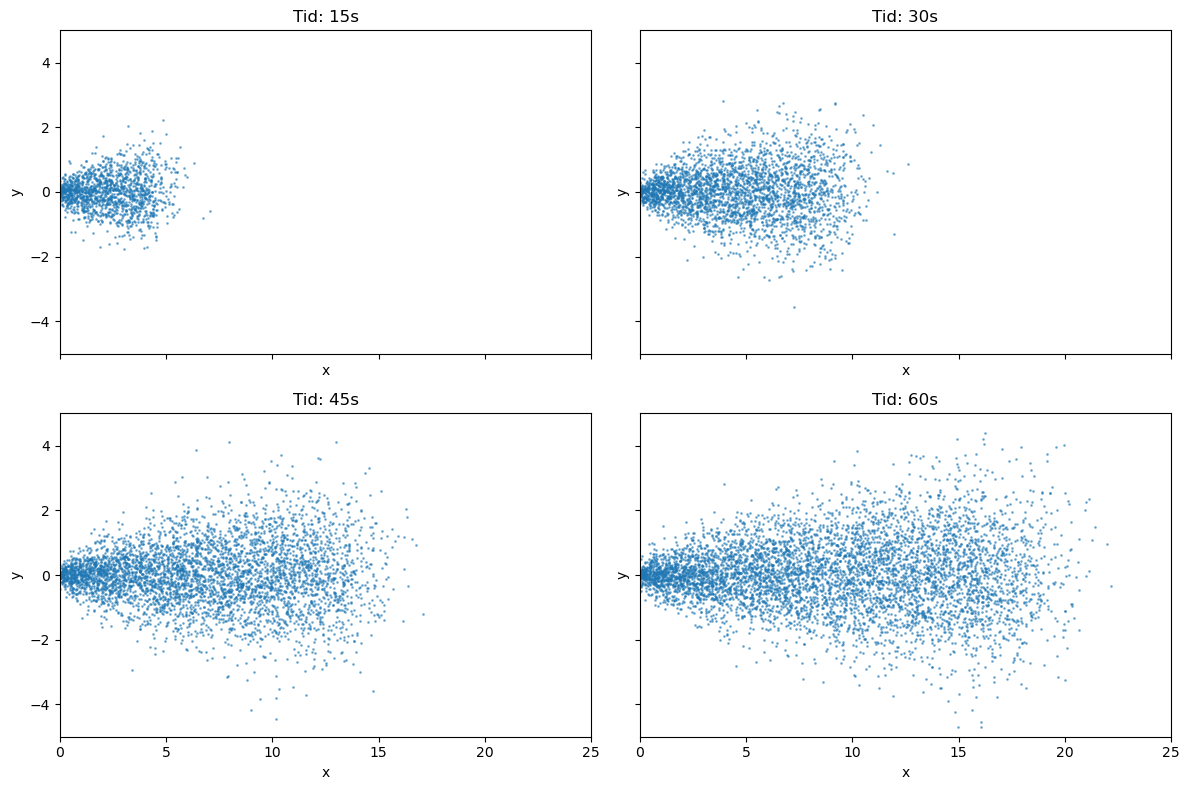

In [8]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

## b

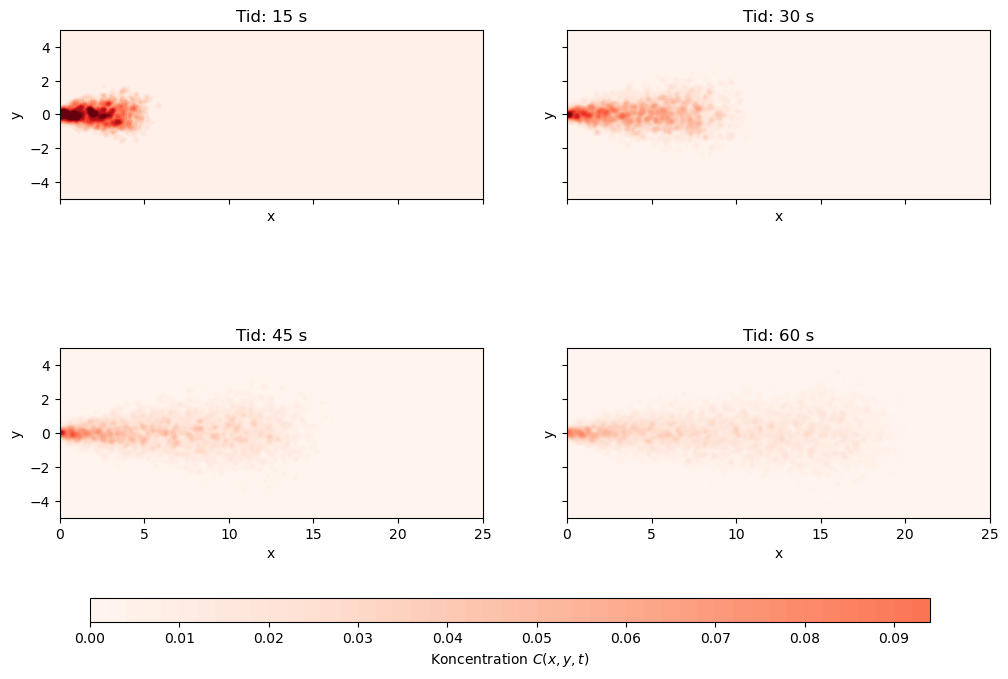

In [9]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

for i in range(len(snapshots)):
    C = compute_concentration(x_grid, y_grid, snapshots[i], epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_aspect('equal')
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Koncentration $C(x,y,t)$')

plt.show()

# Results

In this section, you report the results of each part of the project. To demonstrate that the program works as intended, you include examples of program execution. Present the results in a relevant and appropriate way, like figures, results on the screen etc. If the results contain too much, for example a long list of numbers displayed on the screen, it's recommended to cut it off (and be clear about it in the description). You might also consider making a plot instead of presenting the numbers.
It is important that you convince the reader that you have been able to carry out the mini-project according to the requirements in the mini-project description. You can of course do more than required if you feel it's relevant.



You may plot your necessary figures by executing your code snippets.

Always use `plt.show()` to hide unnecessary output numbers in plt plots. 

# Discussion


In this section you place the additional comments that you find relevant to make, for example, things you might have thought about, things that are unclear, things that would interesting to continue with etc. Some of the mini-projects explicitly contain issues to discuss, and these questions can be addressed in this section.


# References
Here you should include a list of the literature that you use or quote in the report.



# Appendix (if necessary)


Include extended code in an appendix, if any. It might also be other things that do not really fit in the main text that can be included in appendices. For example, it's quite common to see full results in the appendix, and just a few of them in the main text (or just a reference to the appendix in the main text).
